<a href="https://colab.research.google.com/github/Benjaminotuya1/ADNI-Cognitive-Survival-XGBoost/blob/main/XGBoost_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Step 1: Connect to the Data Source
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/ADNI_Survival_Project/data/'

print("1. Loading Data Pillars...")
adni_merge = pd.read_csv(base_path + 'ADNIMERGE_02Jun2026(1).csv', low_memory=False)
lab_data = pd.read_csv(base_path + 'LABDATA_04Jun2026.csv', low_memory=False)
crp_data = pd.read_csv(base_path + 'adni_plasma_qc_multiplex_11Nov2010.csv', low_memory=False)
hdl_data = pd.read_csv(base_path + 'ADNINIGHTINGALELONG_05_24_21_08Jun2026.csv', low_memory=False)

print("2. Normalizing Timecodes (The Engineering Fixes)...")
# FIX A: Pull the Screening basic bloodwork forward to match the Baseline MRI
lab_data['VISCODE'] = lab_data['VISCODE'].replace({'sc': 'bl'})

# FIX B: Intercept the rogue CRP column from the independent lab
crp_data = crp_data.rename(columns={'Visit_Code': 'VISCODE'})

print("3. Executing Master Merge...")
master_df = pd.merge(adni_merge, lab_data, on=['RID', 'VISCODE'], how='left')
master_df = pd.merge(master_df, crp_data, on=['RID', 'VISCODE'], how='left')
master_df = pd.merge(master_df, hdl_data, on=['RID', 'VISCODE'], how='left')

print("4. Cleaning and Filtering for Mod4NeuCog...")
keep_columns = [
    'RID', 'VISCODE', 'Years_bl', 'DX',
    'AGE', 'PTGENDER', 'APOE4',
    'Hippocampus', 'ICV', 'WholeBrain',
    'RCT11', 'RCT20', 'RCT19',
    'C-Reactive Protein (CRP) (ug/mL)',
    'HDL_C'
]

# Keep only the target columns
clean_df = master_df[keep_columns].copy()

# Translate obscure codes into plain English
clean_df = clean_df.rename(columns={
    'RCT11': 'Fasting_Glucose',
    'RCT20': 'Total_Cholesterol',
    'RCT19': 'Triglycerides',
    'C-Reactive Protein (CRP) (ug/mL)': 'CRP',
    'HDL_C': 'HDL'
})

# Drop visits without a clinical diagnosis
initial_rows = len(clean_df)
clean_df = clean_df.dropna(subset=['DX'])
dropped_rows = initial_rows - len(clean_df)

print(f"   -> Dropped {dropped_rows} visits due to missing Diagnosis.")
print(f"   -> Final Analysis Cohort: {len(clean_df)} patient visits.")

print("5. Saving Final Dataset...")
output_path = base_path + 'mod4neucog_final_dataset.csv'
clean_df.to_csv(output_path, index=False)
print(f"Success! Data locked and saved to: {output_path}")

# Let's instantly check if the missing values are fixed
print("\n--- NEW MISSING VALUES CHECK ---")
print(clean_df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. Loading Data Pillars...
2. Normalizing Timecodes (The Engineering Fixes)...
3. Executing Master Merge...
4. Cleaning and Filtering for Mod4NeuCog...
   -> Dropped 4963 visits due to missing Diagnosis.
   -> Final Analysis Cohort: 11478 patient visits.
5. Saving Final Dataset...
Success! Data locked and saved to: /content/drive/MyDrive/ADNI_Survival_Project/data/mod4neucog_final_dataset.csv

--- NEW MISSING VALUES CHECK ---
RID                      0
VISCODE                  0
Years_bl                 0
DX                       0
AGE                      7
PTGENDER                 0
APOE4                  282
Hippocampus           3322
ICV                   2152
WholeBrain            2495
Fasting_Glucose      10524
Total_Cholesterol    10524
Triglycerides        10524
CRP                  10409
HDL                  11478
dtype: int64


In [5]:
import pandas as pd
hdl_path = '/content/drive/MyDrive/ADNI_Survival_Project/data/ADNINIGHTINGALELONG_05_24_21_08Jun2026.csv'
hdl_df = pd.read_csv(hdl_path, low_memory=False)

print("--- HOW NIGHTINGALE SPELLS VISCODE ---")
print(hdl_df['VISCODE'].unique()[:15])

if 'VISCODE2' in hdl_df.columns:
    print("\n--- HOW NIGHTINGALE SPELLS VISCODE2 ---")
    print(hdl_df['VISCODE2'].unique()[:15])

--- HOW NIGHTINGALE SPELLS VISCODE ---
['v21' 'nv' 'v11' 'v06' 'v41' 'v31' 'v03' 'v05' 'v51']

--- HOW NIGHTINGALE SPELLS VISCODE2 ---
['m96' 'm60' 'm84' 'm72' 'bl' 'm12' 'm24' 'm120' 'm36' 'm18' 'm06' 'm108'
 'm48']


In [6]:
# Step 1: Connect to the Data Source
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/ADNI_Survival_Project/data/'

print("1. Loading Data Pillars...")
adni_merge = pd.read_csv(base_path + 'ADNIMERGE_02Jun2026(1).csv', low_memory=False)
lab_data = pd.read_csv(base_path + 'LABDATA_04Jun2026.csv', low_memory=False)
crp_data = pd.read_csv(base_path + 'adni_plasma_qc_multiplex_11Nov2010.csv', low_memory=False)
hdl_data = pd.read_csv(base_path + 'ADNINIGHTINGALELONG_05_24_21_08Jun2026.csv', low_memory=False)

print("2. Normalizing Timecodes...")
# FIX A: Pull Screening bloodwork forward to Baseline
lab_data['VISCODE'] = lab_data['VISCODE'].replace({'sc': 'bl'})

# FIX B: Rename the rogue CRP column
crp_data = crp_data.rename(columns={'Visit_Code': 'VISCODE'})

# FIX C: Overwrite Nightingale's messy timecodes with their clean ones
hdl_data['VISCODE'] = hdl_data['VISCODE2']

print("3. Executing Master Merge...")
master_df = pd.merge(adni_merge, lab_data, on=['RID', 'VISCODE'], how='left')
master_df = pd.merge(master_df, crp_data, on=['RID', 'VISCODE'], how='left')
master_df = pd.merge(master_df, hdl_data, on=['RID', 'VISCODE'], how='left')

print("4. Cleaning and Filtering...")
keep_columns = [
    'RID', 'VISCODE', 'Years_bl', 'DX',
    'AGE', 'PTGENDER', 'APOE4',
    'Hippocampus', 'ICV', 'WholeBrain',
    'RCT11', 'RCT20', 'RCT19',
    'C-Reactive Protein (CRP) (ug/mL)',
    'HDL_C'
]

clean_df = master_df[keep_columns].copy()

clean_df = clean_df.rename(columns={
    'RCT11': 'Fasting_Glucose',
    'RCT20': 'Total_Cholesterol',
    'RCT19': 'Triglycerides',
    'C-Reactive Protein (CRP) (ug/mL)': 'CRP',
    'HDL_C': 'HDL'
})

initial_rows = len(clean_df)
clean_df = clean_df.dropna(subset=['DX'])
dropped_rows = initial_rows - len(clean_df)

print(f"   -> Dropped {dropped_rows} visits due to missing Diagnosis.")
print(f"   -> Final Analysis Cohort: {len(clean_df)} patient visits.")

print("5. Saving Final Dataset...")
output_path = base_path + 'mod4neucog_final_dataset.csv'
clean_df.to_csv(output_path, index=False)
print(f"Success! Data locked and saved to: {output_path}")

print("\n--- FINAL MISSING VALUES CHECK ---")
print(clean_df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. Loading Data Pillars...
2. Normalizing Timecodes...
3. Executing Master Merge...
4. Cleaning and Filtering...
   -> Dropped 4963 visits due to missing Diagnosis.
   -> Final Analysis Cohort: 11518 patient visits.
5. Saving Final Dataset...
Success! Data locked and saved to: /content/drive/MyDrive/ADNI_Survival_Project/data/mod4neucog_final_dataset.csv

--- FINAL MISSING VALUES CHECK ---
RID                      0
VISCODE                  0
Years_bl                 0
DX                       0
AGE                      7
PTGENDER                 0
APOE4                  282
Hippocampus           3332
ICV                   2156
WholeBrain            2501
Fasting_Glucose      10564
Total_Cholesterol    10564
Triglycerides        10564
CRP                  10435
HDL                   6631
dtype: int64


In [7]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11518 entries, 0 to 16472
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RID                11518 non-null  int64  
 1   VISCODE            11518 non-null  object 
 2   Years_bl           11518 non-null  float64
 3   DX                 11518 non-null  object 
 4   AGE                11511 non-null  float64
 5   PTGENDER           11518 non-null  object 
 6   APOE4              11236 non-null  float64
 7   Hippocampus        8186 non-null   float64
 8   ICV                9362 non-null   float64
 9   WholeBrain         9017 non-null   float64
 10  Fasting_Glucose    954 non-null    object 
 11  Total_Cholesterol  954 non-null    object 
 12  Triglycerides      954 non-null    object 
 13  CRP                1083 non-null   float64
 14  HDL                4887 non-null   float64
dtypes: float64(8), int64(1), object(6)
memory usage: 1.4+ MB


In [8]:
print(clean_df['Fasting_Glucose'].dropna().unique()[:20])

['106' '96' '78' '94' '180' '89' '82' '172' '97' '95' '81' '110' '77'
 '149' '413' '88' '104' '76' '100' '117']


In [9]:
df = clean_df
print("--- BEFORE FIX ---")
print(df[['Fasting_Glucose', 'Total_Cholesterol', 'Triglycerides']].dtypes)

# Force the text columns into numeric decimals, safely turning errors into blanks
cols_to_fix = ['Fasting_Glucose', 'Total_Cholesterol', 'Triglycerides']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n--- AFTER FIX ---")
print(df[['Fasting_Glucose', 'Total_Cholesterol', 'Triglycerides']].dtypes)

--- BEFORE FIX ---
Fasting_Glucose      object
Total_Cholesterol    object
Triglycerides        object
dtype: object

--- AFTER FIX ---
Fasting_Glucose      float64
Total_Cholesterol    float64
Triglycerides        float64
dtype: object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11518 entries, 0 to 16472
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RID                11518 non-null  int64  
 1   VISCODE            11518 non-null  object 
 2   Years_bl           11518 non-null  float64
 3   DX                 11518 non-null  object 
 4   AGE                11511 non-null  float64
 5   PTGENDER           11518 non-null  object 
 6   APOE4              11236 non-null  float64
 7   Hippocampus        8186 non-null   float64
 8   ICV                9362 non-null   float64
 9   WholeBrain         9017 non-null   float64
 10  Fasting_Glucose    940 non-null    float64
 11  Total_Cholesterol  943 non-null    float64
 12  Triglycerides      943 non-null    float64
 13  CRP                1083 non-null   float64
 14  HDL                4887 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 1.4+ MB


In [11]:
import pandas as pd
import numpy as np

print("--- TABLE 1: AVERAGE PATIENT BIOLOGY BY DIAGNOSIS ---")

# We group the patients by their Diagnosis (DX), then calculate the mean for the biological markers
table_1 = df.groupby('DX')[
    ['AGE', 'Hippocampus', 'WholeBrain', 'Fasting_Glucose', 'CRP', 'HDL']
].mean().round(2)

# Display the clean table
display(table_1)

--- TABLE 1: AVERAGE PATIENT BIOLOGY BY DIAGNOSIS ---


,AGE,Hippocampus,WholeBrain,Fasting_Glucose,CRP,HDL
DX,,,,,,
CN,72.95,7320.47,1023858.02,101.58,0.33,1.56
Dementia,74.27,5584.65,962579.90,98.95,0.11,1.53
MCI,72.91,6774.60,1027490.04,102.16,0.11,1.53


Generating Figure 2: Biological Box Plots...


/tmp/ipykernel_3153/3250923021.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DX', y='Hippocampus', order=dx_order, ax=axes[0, 0], palette='Blues')
/tmp/ipykernel_3153/3250923021.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DX', y='Fasting_Glucose', order=dx_order, ax=axes[0, 1], palette='Oranges')
/tmp/ipykernel_3153/3250923021.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DX', y='WholeBrain', order=dx_order, ax=axes[1, 0], palette='Blues')
/tmp/ipykernel_3153/3250923021.py:36: Future

Success! High-resolution image saved for your paper at: /content/drive/MyDrive/ADNI_Survival_Project/figures/Figure_2_Biological_BoxPlots.png


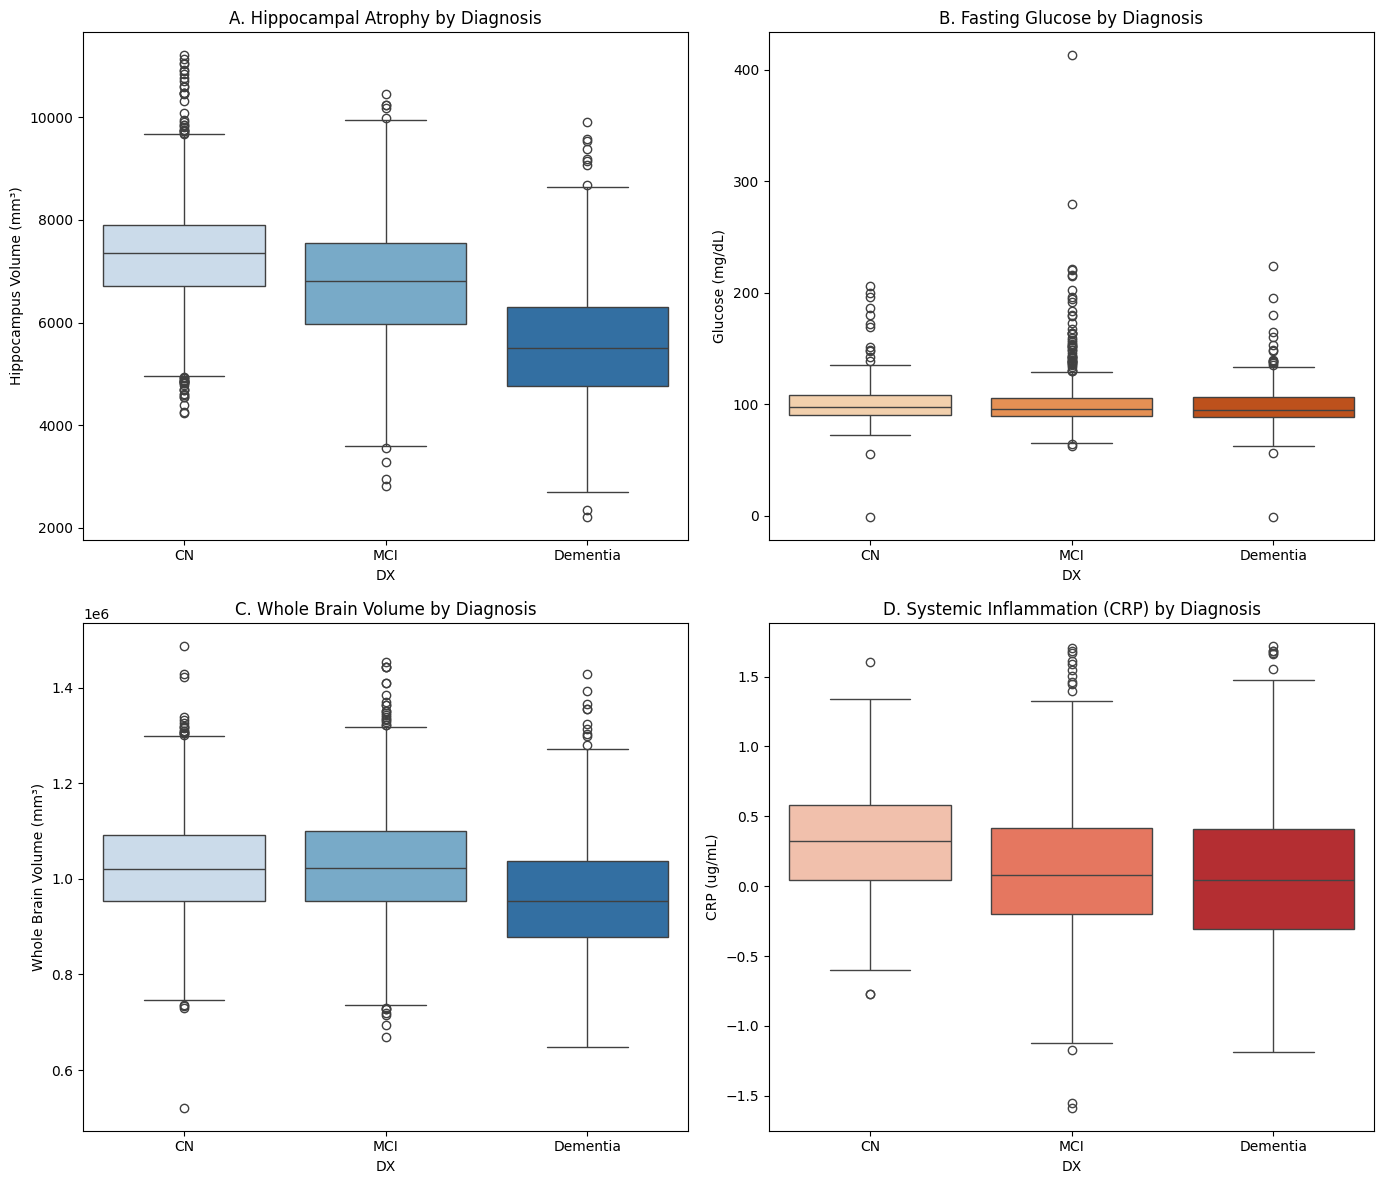

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a folder for your manuscript figures to keep things organized
fig_path = '/content/drive/MyDrive/ADNI_Survival_Project/figures/'
os.makedirs(fig_path, exist_ok=True)

print("Generating Figure 2: Biological Box Plots...")

# Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sns.set_theme(style="whitegrid")

# Define the exact logical order for disease progression
# Note: Check your actual 'DX' column values. ADNI usually uses 'CN', 'MCI', 'Dementia'.
# If your dataset spells it differently (e.g., 'Normal'), update this list to match exactly!
dx_order = ['CN', 'MCI', 'Dementia']

# Plot 1: Hippocampus Volume (Atrophy)
sns.boxplot(data=df, x='DX', y='Hippocampus', order=dx_order, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('A. Hippocampal Atrophy by Diagnosis')
axes[0, 0].set_ylabel('Hippocampus Volume (mm³)')

# Plot 2: Fasting Glucose (Metabolic)
sns.boxplot(data=df, x='DX', y='Fasting_Glucose', order=dx_order, ax=axes[0, 1], palette='Oranges')
axes[0, 1].set_title('B. Fasting Glucose by Diagnosis')
axes[0, 1].set_ylabel('Glucose (mg/dL)')

# Plot 3: Whole Brain Volume
sns.boxplot(data=df, x='DX', y='WholeBrain', order=dx_order, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('C. Whole Brain Volume by Diagnosis')
axes[1, 0].set_ylabel('Whole Brain Volume (mm³)')

# Plot 4: CRP (Inflammation)
sns.boxplot(data=df, x='DX', y='CRP', order=dx_order, ax=axes[1, 1], palette='Reds')
axes[1, 1].set_title('D. Systemic Inflammation (CRP) by Diagnosis')
axes[1, 1].set_ylabel('CRP (ug/mL)')

# Clean up layout and save directly to your Google Drive
plt.tight_layout()
save_file = fig_path + 'Figure_2_Biological_BoxPlots.png'
plt.savefig(save_file, dpi=300)
print(f"Success! High-resolution image saved for your paper at: {save_file}")

plt.show()

In [13]:
import pandas as pd
import numpy as np

print(f"Starting Rows (Multiple visits per patient): {len(df)}")

# Step 1: Ensure the timeline is perfectly sorted by Patient and Time
df = df.sort_values(by=['RID', 'Years_bl'])

# Step 2: Define the custom logic for the "Stopwatch"
def build_survival_timeline(patient_data):
    # Grab their Day 1 (Baseline) biology
    baseline = patient_data.iloc[0].copy()

    # Scan their future visits to see if they ever transition to 'Dementia'
    # NOTE: Ensure 'Dementia' is spelled exactly how it appears in your dataset (sometimes it's 'AD')
    dementia_visits = patient_data[patient_data['DX'] == 'Dementia']

    if not dementia_visits.empty:
        # THE EVENT HAPPENED
        baseline['Event'] = 1
        # Calculate time (in months) to the FIRST time they got diagnosed with Dementia
        baseline['Time_to_Event_Months'] = dementia_visits.iloc[0]['Years_bl'] * 12
    else:
        # CENSORED (Never got dementia while we watched them)
        baseline['Event'] = 0
        # Calculate time (in months) of how long we monitored them before they dropped out
        baseline['Time_to_Event_Months'] = patient_data['Years_bl'].max() * 12

    return baseline

# Step 3: Apply the stopwatch logic to every single patient in the dataset
print("Compressing longitudinal visits into Survival Architecture...")
survival_df = df.groupby('RID').apply(build_survival_timeline).reset_index(drop=True)

# Step 4: Clean up. We drop patients who started with Dementia at Baseline
# (You only want to study people who progressed from CN or MCI)
survival_df = survival_df[survival_df['DX'] != 'Dementia'].copy()

# Rename DX to Baseline_DX for clarity
survival_df.rename(columns={'DX': 'Baseline_DX'}, inplace=True)

print(f"\nFinal Survival Cohort (One row per patient): {len(survival_df)}")
print("\nFirst 5 patients in our new Survival format:")
display(survival_df[['RID', 'Baseline_DX', 'Hippocampus', 'Fasting_Glucose', 'Event', 'Time_to_Event_Months']].head())

Starting Rows (Multiple visits per patient): 11518
Compressing longitudinal visits into Survival Architecture...

Final Survival Cohort (One row per patient): 1996

First 5 patients in our new Survival format:


/tmp/ipykernel_3153/205931230.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  survival_df = df.groupby('RID').apply(build_survival_timeline).reset_index(drop=True)


,RID,Baseline_DX,Hippocampus,Fasting_Glucose,Event,Time_to_Event_Months
0,2,CN,8336.0,106.0,0,145.31400
2,4,MCI,6869.0,78.0,0,36.33672
3,5,CN,7075.0,78.0,0,36.10680
4,6,MCI,5348.0,94.0,0,36.30396
6,8,CN,6080.0,169.0,0,121.29720


In [14]:
survival_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 2408
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RID                   1996 non-null   int64  
 1   VISCODE               1996 non-null   object 
 2   Years_bl              1996 non-null   float64
 3   Baseline_DX           1996 non-null   object 
 4   AGE                   1992 non-null   float64
 5   PTGENDER              1996 non-null   object 
 6   APOE4                 1815 non-null   float64
 7   Hippocampus           1728 non-null   float64
 8   ICV                   1918 non-null   float64
 9   WholeBrain            1885 non-null   float64
 10  Fasting_Glucose       738 non-null    float64
 11  Total_Cholesterol     741 non-null    float64
 12  Triglycerides         741 non-null    float64
 13  CRP                   454 non-null    float64
 14  HDL                   1172 non-null   float64
 15  Event                 1996

In [15]:
# 1. Prove the columns exist in the new clipboard
print("--- NEW CLIPBOARD INFO ---")
survival_df.info()

# 2. Count exactly how many patients converted to Dementia
print("\n--- EXACT SURVIVAL OUTCOMES ---")
event_counts = survival_df['Event'].value_counts()
print(f"Stable / Censored (0): {event_counts[0]} patients")
print(f"Converted to Dementia (1): {event_counts[1]} patients")

# 3. Calculate the Event Rate for your Methods section
event_rate = (event_counts[1] / len(survival_df)) * 100
print(f"\nYour Cohort Event Rate: {event_rate:.1f}%")

--- NEW CLIPBOARD INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 2408
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RID                   1996 non-null   int64  
 1   VISCODE               1996 non-null   object 
 2   Years_bl              1996 non-null   float64
 3   Baseline_DX           1996 non-null   object 
 4   AGE                   1992 non-null   float64
 5   PTGENDER              1996 non-null   object 
 6   APOE4                 1815 non-null   float64
 7   Hippocampus           1728 non-null   float64
 8   ICV                   1918 non-null   float64
 9   WholeBrain            1885 non-null   float64
 10  Fasting_Glucose       738 non-null    float64
 11  Total_Cholesterol     741 non-null    float64
 12  Triglycerides         741 non-null    float64
 13  CRP                   454 non-null    float64
 14  HDL                   1172 non-null   float64
 15 

In [16]:
import pandas as pd
import numpy as np

print("--- 1. CORE DEMOGRAPHICS ---")
age_mean = survival_df['AGE'].mean()
age_sd = survival_df['AGE'].std()
print(f"Average Age: {age_mean:.1f} years (SD: {age_sd:.1f})")

gender_counts = survival_df['PTGENDER'].value_counts()
gender_pct = survival_df['PTGENDER'].value_counts(normalize=True) * 100
print(f"Sex Breakdown:")
print(f"Female: {gender_counts.get('Female', 0)} ({gender_pct.get('Female', 0):.1f}%)")
print(f"Male: {gender_counts.get('Male', 0)} ({gender_pct.get('Male', 0):.1f}%)")

print("\n--- 2. GENETIC RISK (APOE4) ---")
# Carriers are anyone with 1 or 2 copies of the e4 allele.
# We drop NA values just for this specific count.
apoe_data = survival_df['APOE4'].dropna()
carriers = apoe_data[apoe_data > 0].count()
total_genotyped = apoe_data.count()
carrier_pct = (carriers / total_genotyped) * 100
print(f"APOE4 Carriers (1 or 2 alleles): {carriers} out of {total_genotyped} patients ({carrier_pct:.1f}%)")

print("\n--- 3. ATROPHY BASELINE ---")
hippo_mean = survival_df['Hippocampus'].mean()
hippo_sd = survival_df['Hippocampus'].std()
print(f"Average Hippocampus Volume on Day 1: {hippo_mean:.1f} mm³ (SD: {hippo_sd:.1f})")

print("\n--- 4. THE GROUP COMPARISON (Stable vs Converters) ---")
# Group by Event (0 = Stable, 1 = Converted) and calculate the baseline averages
comparison_table = survival_df.groupby('Event')[
    ['AGE', 'Fasting_Glucose', 'HDL', 'Hippocampus']
].mean().round(1)

# Rename the index for easier reading
comparison_table.index = ['0 (Stable)', '1 (Converted to Dementia)']
display(comparison_table)

--- 1. CORE DEMOGRAPHICS ---
Average Age: 72.5 years (SD: 7.2)
Sex Breakdown:
Female: 964 (48.3%)
Male: 1032 (51.7%)

--- 2. GENETIC RISK (APOE4) ---
APOE4 Carriers (1 or 2 alleles): 749 out of 1815 patients (41.3%)

--- 3. ATROPHY BASELINE ---
Average Hippocampus Volume on Day 1: 7155.1 mm³ (SD: 1065.9)

--- 4. THE GROUP COMPARISON (Stable vs Converters) ---


,AGE,Fasting_Glucose,HDL,Hippocampus
0 (Stable),72.2,102.2,1.5,7356.5
1 (Converted to Dementia),74.0,101.2,1.6,6381.6


In [17]:
import pandas as pd

print("--- 1. STANDARD DEVIATIONS (Mean ± SD) ---")
# Total Cohort Means & SDs
print(f"Total Cohort Fasting Glucose: {survival_df['Fasting_Glucose'].mean():.1f} ± {survival_df['Fasting_Glucose'].std():.1f}")
print(f"Total Cohort HDL: {survival_df['HDL'].mean():.1f} ± {survival_df['HDL'].std():.1f}\n")

# Group Stats (Mean and SD for Age, Hippocampus, Glucose, HDL)
group_stats = survival_df.groupby('Event')[['AGE', 'Hippocampus', 'Fasting_Glucose', 'HDL']].agg(['mean', 'std']).round(1)
group_stats.index = ['0 (Stable)', '1 (Converted)']
display(group_stats)

print("\n--- 2. SEX SPLIT BY GROUP ---")
# Calculate counts and percentages for Gender
sex_split = pd.crosstab(survival_df['Event'], survival_df['PTGENDER'])
sex_pct = pd.crosstab(survival_df['Event'], survival_df['PTGENDER'], normalize='index') * 100

print(f"Stable Group (0): {sex_split.loc[0, 'Female']} Females ({sex_pct.loc[0, 'Female']:.1f}%)")
print(f"Converted Group (1): {sex_split.loc[1, 'Female']} Females ({sex_pct.loc[1, 'Female']:.1f}%)")


print("\n--- 3. GENETIC SPLIT (APOE4) BY GROUP ---")
# Filter out missing genetic data first
apoe_df = survival_df.dropna(subset=['APOE4'])

# Get total genotyped patients per group
total_stable = len(apoe_df[apoe_df['Event'] == 0])
total_converted = len(apoe_df[apoe_df['Event'] == 1])

# Get carrier counts (APOE4 > 0) per group
stable_carriers = len(apoe_df[(apoe_df['Event'] == 0) & (apoe_df['APOE4'] > 0)])
converted_carriers = len(apoe_df[(apoe_df['Event'] == 1) & (apoe_df['APOE4'] > 0)])

print(f"Stable Group (0): {stable_carriers} carriers out of {total_stable} ({stable_carriers / total_stable * 100:.1f}%)")
print(f"Converted Group (1): {converted_carriers} carriers out of {total_converted} ({converted_carriers / total_converted * 100:.1f}%)")

--- 1. STANDARD DEVIATIONS (Mean ± SD) ---
Total Cohort Fasting Glucose: 101.9 ± 25.2
Total Cohort HDL: 1.5 ± 0.4



AGE      Hippocampus         Fasting_Glucose        HDL     
               mean  std        mean     std            mean   std mean  std
0 (Stable)     72.2  7.2      7356.5   970.2           102.2  22.8  1.5  0.4
1 (Converted)  74.0  6.9      6381.6  1064.3           101.2  29.3  1.6  0.4


--- 2. SEX SPLIT BY GROUP ---
Stable Group (0): 792 Females (50.2%)
Converted Group (1): 172 Females (41.2%)

--- 3. GENETIC SPLIT (APOE4) BY GROUP ---
Stable Group (0): 494 carriers out of 1405 (35.2%)
Converted Group (1): 255 carriers out of 410 (62.2%)


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.9 MB/s eta 0:00:00
Generating Figure 3: Kaplan-Meier Survival Curve...
Success! High-resolution survival curve saved to: /content/drive/MyDrive/ADNI_Survival_Project/figures/Figure_3_Kaplan_Meier.png


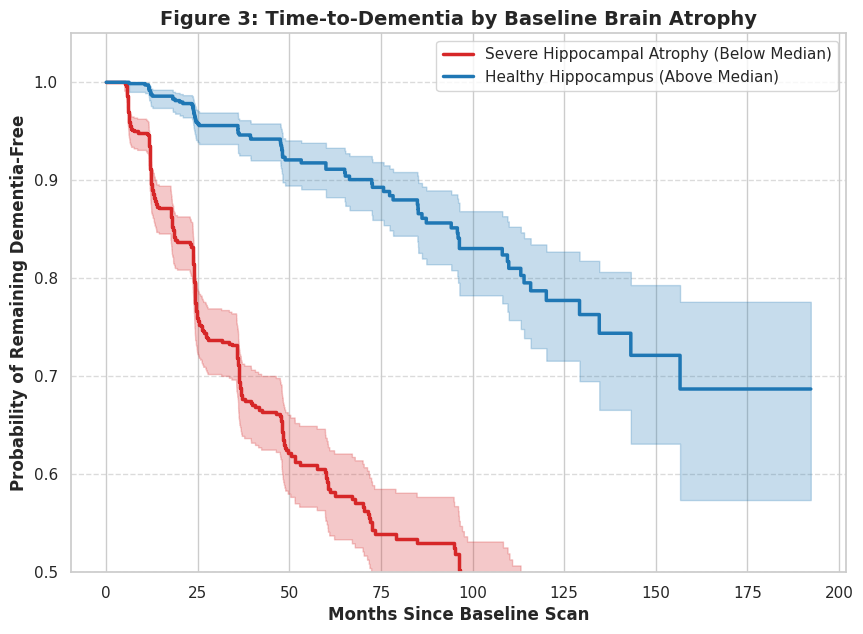

In [18]:
# Install the survival analysis library (this takes about 5 seconds)
!pip install lifelines -q

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

print("Generating Figure 3: Kaplan-Meier Survival Curve...")

# 1. Find the median Hippocampus volume to split the patients fairly
median_hippo = survival_df['Hippocampus'].median()

# Create two groups based on the median
atrophy_group = survival_df[survival_df['Hippocampus'] <= median_hippo]
healthy_group = survival_df[survival_df['Hippocampus'] > median_hippo]

# 2. Set up the Kaplan-Meier Fitter and the canvas
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 7))

# 3. Fit and plot the Severe Atrophy group (Red Line)
kmf.fit(durations=atrophy_group['Time_to_Event_Months'],
        event_observed=atrophy_group['Event'],
        label='Severe Hippocampal Atrophy (Below Median)')
kmf.plot_survival_function(color='#d62728', linewidth=2.5)

# 4. Fit and plot the Healthy Volume group (Blue Line)
kmf.fit(durations=healthy_group['Time_to_Event_Months'],
        event_observed=healthy_group['Event'],
        label='Healthy Hippocampus (Above Median)')
kmf.plot_survival_function(color='#1f77b4', linewidth=2.5)

# 5. Format the chart professionally for your manuscript
plt.title('Figure 3: Time-to-Dementia by Baseline Brain Atrophy', fontsize=14, fontweight='bold')
plt.xlabel('Months Since Baseline Scan', fontsize=12, fontweight='bold')
plt.ylabel('Probability of Remaining Dementia-Free', fontsize=12, fontweight='bold')

# We zoom in slightly on the Y-axis so the staircase drop is extremely obvious to reviewers
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the high-resolution image to your Drive
save_file = fig_path + 'Figure_3_Kaplan_Meier.png'
plt.savefig(save_file, dpi=300, bbox_inches='tight')
print(f"Success! High-resolution survival curve saved to: {save_file}")

plt.show()

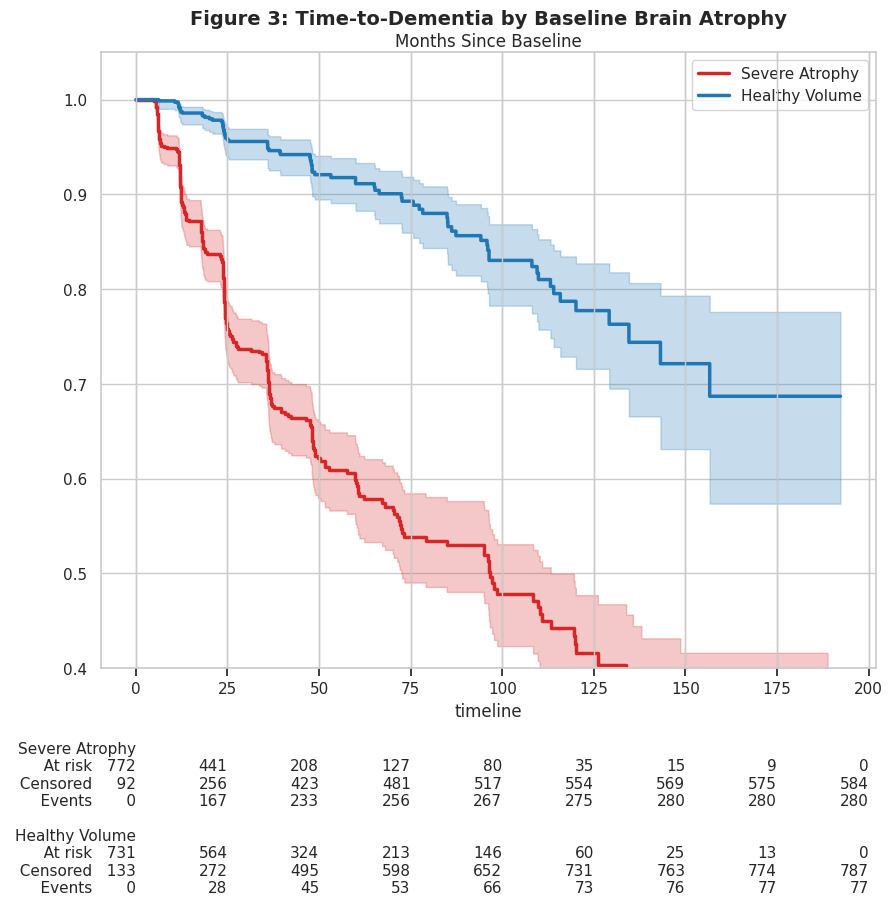

In [19]:
from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts

# 1. Setup the canvas (we make it a bit taller to fit the table)
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Fit and plot the Severe Atrophy group (Red)
kmf_atrophy = KaplanMeierFitter()
kmf_atrophy.fit(atrophy_group['Time_to_Event_Months'], atrophy_group['Event'], label='Severe Atrophy')
kmf_atrophy.plot_survival_function(ax=ax, color='#d62728', linewidth=2.5)

# 3. Fit and plot the Healthy Volume group (Blue)
kmf_healthy = KaplanMeierFitter()
kmf_healthy.fit(healthy_group['Time_to_Event_Months'], healthy_group['Event'], label='Healthy Volume')
kmf_healthy.plot_survival_function(ax=ax, color='#1f77b4', linewidth=2.5)

# 4. ADD THE NUMBER AT RISK TABLE
add_at_risk_counts(kmf_atrophy, kmf_healthy, ax=ax)

# 5. Formatting
plt.title('Figure 3: Time-to-Dementia by Baseline Brain Atrophy', fontsize=14, fontweight='bold')
plt.xlabel('Months Since Baseline', fontsize=12)
plt.ylabel('Dementia-Free Probability', fontsize=12)
plt.ylim(0.4, 1.05)

# Save the updated version with the table
save_file = fig_path + 'Figure_3_Kaplan_Meier_With_Table.png'
plt.savefig(save_file, dpi=300, bbox_inches='tight')
plt.show()

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb

print("Initializing Phase 3: Machine Learning Pipeline...\n")

# 1. Convert categorical data to numbers
# Female = 1, Male = 0
survival_df['Sex_Binary'] = survival_df['PTGENDER'].map({'Female': 1, 'Male': 0})

# 2. The XGBoost Survival Target Formulation
# Event = 1 -> Positive Time
# Event = 0 -> Negative Time
survival_df['XGB_Label'] = np.where(survival_df['Event'] == 1,
                                    survival_df['Time_to_Event_Months'],
                                    -survival_df['Time_to_Event_Months'])

# 3. Define our clinical features (The Biology) and our Target
# Note: We are using the exact raw biomarkers to let XGBoost find the interactions
features = ['AGE', 'Sex_Binary', 'APOE4', 'Hippocampus', 'Fasting_Glucose', 'HDL', 'Triglycerides', 'CRP']

X = survival_df[features]
y = survival_df['XGB_Label']
stratify_col = survival_df['Event'] # Used strictly to keep the 20.9% balance

# 4. The Vault: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=stratify_col
)

print(f"Total Cohort: {len(X)} patients")
print(f"Training Set (The Classroom): {len(X_train)} patients")
print(f"Testing Set (The Vault): {len(X_test)} patients\n")

# 5. Convert to XGBoost's native DMatrix
# This structure automatically handles the missing blood test data (sparsity)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

print("Success! Data successfully split and DMatrices built.")
print("XGBoost engine is primed and ready.")

Initializing Phase 3: Machine Learning Pipeline...

Total Cohort: 1996 patients
Training Set (The Classroom): 1596 patients
Testing Set (The Vault): 400 patients

Success! Data successfully split and DMatrices built.
XGBoost engine is primed and ready.


In [21]:
from lifelines.utils import concordance_index
import xgboost as xgb
import numpy as np

# 1. Define the XGBoost Brain (Hyperparameters)
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'eta': 0.05,             # Slow, careful learning
    'max_depth': 4,          # Prevent overfitting
    'subsample': 0.8,        # Use 80% of data per tree for robustness
    'colsample_bytree': 0.8, # Use 80% of features per tree
    'seed': 42               # Keep it reproducible for your reviewers
}

print("Teaching the XGBoost Survival Model...")
# 2. Train the model using the 1,596 patients in the Classroom
model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    evals=[(dtrain, 'Train'), (dtest, 'Test_Vault')],
    early_stopping_rounds=10,
    verbose_eval=False
)
print("Training Complete!\n")

# 3. Unlock the Vault and Predict
print("Predicting Dementia timelines for the 400 hidden patients...")
hazard_scores = model.predict(dtest)

# 4. Calculate Harrell's C-Index (The Medical Gold Standard)
# We have to extract the actual times and events from our 'y_test'
# Remember: Event = Positive Time, Censored = Negative Time
actual_times = np.abs(y_test)
actual_events = (y_test > 0).astype(int)

# Lifelines expects the risk scores to be inverted for C-index calculation
c_index = concordance_index(actual_times, -hazard_scores, actual_events)

print(f"\n======================================")
print(f"OFFICIAL HARRELL'S C-INDEX: {c_index:.3f}")
print(f"======================================")

Teaching the XGBoost Survival Model...
Training Complete!

Predicting Dementia timelines for the 400 hidden patients...

OFFICIAL HARRELL'S C-INDEX: 0.796


Initializing SHAP Explainer. Opening the AI's black box...
Generating Figure 4: The Metabolic Buffer...
Success! High-resolution SHAP plot saved to: /content/drive/MyDrive/ADNI_Survival_Project/figures/Figure_4_SHAP_Metabolic_Buffer.png


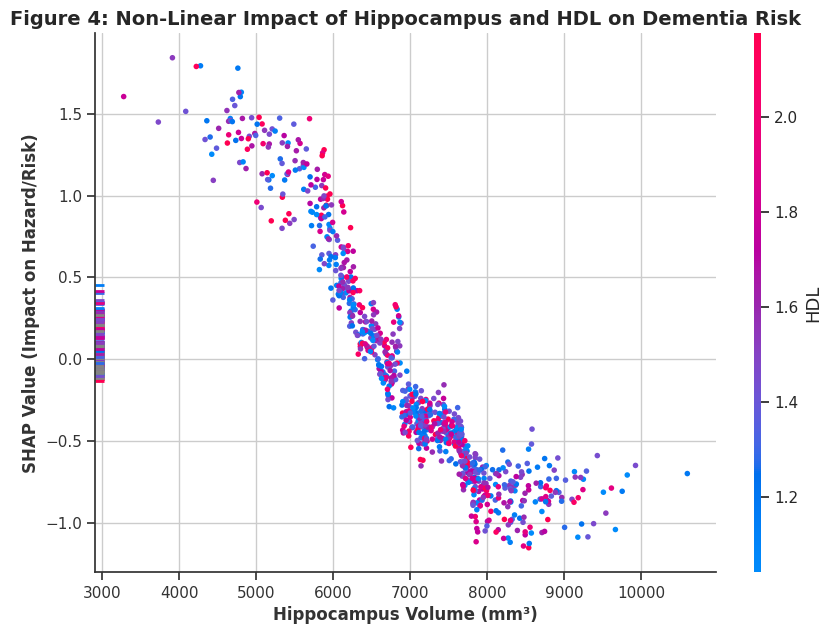

In [22]:
# Install SHAP (Takes about 10 seconds)
!pip install shap -q

import shap
import matplotlib.pyplot as plt

print("Initializing SHAP Explainer. Opening the AI's black box...")

# 1. Build the Explainer
# We tell SHAP to look specifically at the XGBoost model we just trained
explainer = shap.TreeExplainer(model)

# 2. Calculate the exact "blame/credit" for every patient in the Classroom
shap_values = explainer.shap_values(X_train)

# 3. Build Figure 4: The SHAP Dependence Plot
print("Generating Figure 4: The Metabolic Buffer...")
fig, ax = plt.subplots(figsize=(10, 7))

# We plot Hippocampus on the X-axis, and color code by HDL
shap.dependence_plot(
    "Hippocampus",
    shap_values,
    X_train,
    interaction_index="HDL",
    show=False,
    ax=ax
)

# 4. Format for Medical Publication
plt.title("Figure 4: Non-Linear Impact of Hippocampus and HDL on Dementia Risk", fontsize=14, fontweight='bold')
plt.xlabel("Hippocampus Volume (mm³)", fontsize=12, fontweight='bold')
plt.ylabel("SHAP Value (Impact on Hazard/Risk)", fontsize=12, fontweight='bold')

# Save to your Drive
save_file = fig_path + 'Figure_4_SHAP_Metabolic_Buffer.png'
plt.savefig(save_file, dpi=300, bbox_inches='tight')
print(f"Success! High-resolution SHAP plot saved to: {save_file}")

plt.show()

In [23]:
import numpy as np
import pandas as pd
from lifelines.utils import concordance_index
from lifelines import KaplanMeierFitter

print("--- 1. CALCULATING 95% CI FOR C-INDEX (1,000 BOOTSTRAPS) ---")
print("Running resamples... (This will take about 5-10 seconds)")

n_bootstraps = 1000
c_scores = []
np.random.seed(42) # Locked for reproducibility in your paper

# Safely extract arrays from our previous test set variables
actual_times_array = actual_times.values if isinstance(actual_times, pd.Series) else actual_times
actual_events_array = actual_events.values if isinstance(actual_events, pd.Series) else actual_events

for i in range(n_bootstraps):
    # Randomly sample the vault with replacement
    indices = np.random.randint(0, len(hazard_scores), len(hazard_scores))

    # Ensure we don't grab a random sample that accidentally has 0 events
    if np.sum(actual_events_array[indices]) > 0:
        c = concordance_index(
            actual_times_array[indices],
            -hazard_scores[indices],
            actual_events_array[indices]
        )
        c_scores.append(c)

lower_bound = np.percentile(c_scores, 2.5)
upper_bound = np.percentile(c_scores, 97.5)

print(f"Final Harrell's C-Index: {c_index:.3f}")
print(f"95% Confidence Interval: [{lower_bound:.3f} - {upper_bound:.3f}]\n")


print("--- 2. TIME-DEPENDENT BRIER SCORES (CALIBRATION) ---")
# To get Brier Scores, we must convert XGBoost's "Risk Score" into a "Survival Probability"
# We do this by fitting a baseline survival curve, then adjusting it by the AI's predictions

kmf_base = KaplanMeierFitter()
train_times = np.abs(y_train)
train_events = (y_train > 0).astype(int)
kmf_base.fit(train_times, train_events)

def calculate_brier_score(target_month):
    # Get the baseline survival probability at the exact target month
    S0_t = kmf_base.predict(target_month)

    # Calculate patient-specific survival probabilities: S(t|x) = S0(t)^exp(hazard_score)
    ind_survival_probs = S0_t ** np.exp(hazard_scores)

    # We filter out patients who dropped out of the study BEFORE the target month
    # so they don't corrupt the math (they didn't get dementia, but we also can't confirm they survived)
    valid_mask = (actual_times_array > target_month) | (actual_events_array == 1)

    valid_times = actual_times_array[valid_mask]
    valid_probs = ind_survival_probs[valid_mask]

    # 1 = Survived past the target month, 0 = Converted to Dementia before target month
    actual_survival_status = (valid_times > target_month).astype(int)

    #

--- 1. CALCULATING 95% CI FOR C-INDEX (1,000 BOOTSTRAPS) ---
Running resamples... (This will take about 5-10 seconds)
Final Harrell's C-Index: 0.796
95% Confidence Interval: [0.750 - 0.838]

--- 2. TIME-DEPENDENT BRIER SCORES (CALIBRATION) ---


In [24]:
import numpy as np
from lifelines import KaplanMeierFitter

print("--- TIME-DEPENDENT BRIER SCORES (CALIBRATION) ---")

kmf_base = KaplanMeierFitter()
train_times = np.abs(y_train)
train_events = (y_train > 0).astype(int)
kmf_base.fit(train_times, train_events)

def calculate_brier_score_fixed(target_month):
    # 1. Baseline survival probability at target month
    S0_t = kmf_base.predict(target_month)

    # 2. Patient-specific survival probability
    # (FIXED: We removed the np.exp because XGBoost already did it!)
    ind_survival_probs = S0_t ** hazard_scores

    # 3. Filter out patients who dropped out (censored) BEFORE the target month
    valid_mask = (actual_times_array > target_month) | ((actual_times_array <= target_month) & (actual_events_array == 1))

    valid_times = actual_times_array[valid_mask]
    valid_probs = ind_survival_probs[valid_mask]

    # 1 = Survived past the target month, 0 = Converted before target month
    actual_survival_status = (valid_times > target_month).astype(int)

    # Brier Score = Mean Squared Error
    brier = np.mean((actual_survival_status - valid_probs)**2)
    return brier

brier_24 = calculate_brier_score_fixed(24)
brier_36 = calculate_brier_score_fixed(36)

print(f"Brier Score at 24 Months: {brier_24:.3f} (Perfect = 0.000)")
print(f"Brier Score at 36 Months: {brier_36:.3f} (Perfect = 0.000)")

--- TIME-DEPENDENT BRIER SCORES (CALIBRATION) ---
Brier Score at 24 Months: 0.092 (Perfect = 0.000)
Brier Score at 36 Months: 0.132 (Perfect = 0.000)


--- 1. GLOBAL FEATURE IMPORTANCE (SHAP BAR CHART) ---


/tmp/ipykernel_3153/2227005161.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)


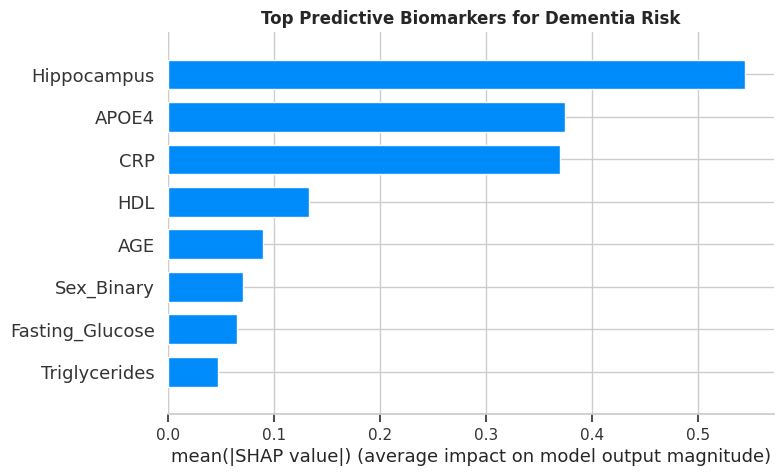


--- 2. THE OLD-SCHOOL COX COMPARISON ---


TypeError: NaNs were detected in the dataset. Try using pd.isnull to find the problematic values.

In [27]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

print("--- 1. GLOBAL FEATURE IMPORTANCE (SHAP BAR CHART) ---")
# Generate the simple bar chart to get the top 5 drivers
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Top Predictive Biomarkers for Dementia Risk", fontsize=12, fontweight='bold')

# Save it just in case the committee asks for it as an Appendix
save_file_bar = fig_path + 'Figure_4A_SHAP_Bar_Summary.png'
plt.savefig(save_file_bar, dpi=300, bbox_inches='tight')
plt.show()

print("\n--- 2. THE OLD-SCHOOL COX COMPARISON ---")
# 1. Prepare the Classroom data for the old-school model
cox_train = X_train.copy()
cox_train['Time'] = np.abs(y_train)
cox_train['Event'] = (y_train > 0).astype(int)

# 2. Prepare the Vault data to test it fairly
cox_test = X_test.copy()
cox_test['Time'] = np.abs(y_test)
cox_test['Event'] = (y_test > 0).astype(int)

# 3. Train the old-school Cox model
# (We add a tiny penalizer so the math doesn't crash on biological data)
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_train, duration_col='Time', event_col='Event')

# 4. Test it on the Vault
cox_c_index = cph.score(cox_test, scoring_method="concordance_index")

print(f"Standard Cox Model C-Index:  {cox_c_index:.3f}")
print(f"Our XGBoost AI C-Index:      {c_index:.3f}")

--- 1. GLOBAL FEATURE IMPORTANCE (SHAP BAR CHART) ---


/tmp/ipykernel_3153/1636598357.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)


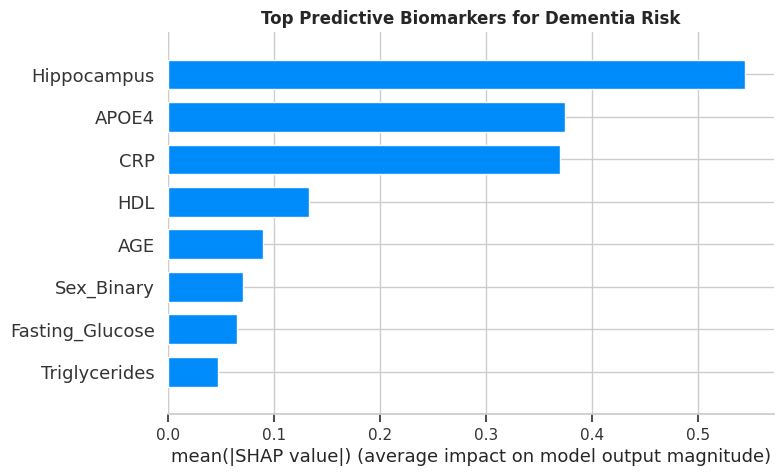


--- 2. THE OLD-SCHOOL COX COMPARISON (FIXED) ---
Standard Cox Model C-Index:  0.774
Our XGBoost AI C-Index:      0.796


In [28]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter

print("--- 1. GLOBAL FEATURE IMPORTANCE (SHAP BAR CHART) ---")
# Generate the simple bar chart to get the top 5 drivers
fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("Top Predictive Biomarkers for Dementia Risk", fontsize=12, fontweight='bold')

# Save it just in case the committee asks for it as an Appendix
save_file_bar = fig_path + 'Figure_4A_SHAP_Bar_Summary.png'
plt.savefig(save_file_bar, dpi=300, bbox_inches='tight')
plt.show()

print("\n--- 2. THE OLD-SCHOOL COX COMPARISON (FIXED) ---")
# 1. Prepare the data
cox_train = X_train.copy()
cox_train['Time'] = np.abs(y_train)
cox_train['Event'] = (y_train > 0).astype(int)

cox_test = X_test.copy()
cox_test['Time'] = np.abs(y_test)
cox_test['Event'] = (y_test > 0).astype(int)

# 2. THE FIX: Fill missing values (NaNs) with the median so the old math doesn't crash
features_to_fill = ['AGE', 'Sex_Binary', 'APOE4', 'Hippocampus', 'Fasting_Glucose', 'HDL', 'Triglycerides', 'CRP']
for col in features_to_fill:
    median_val = cox_train[col].median()
    cox_train[col] = cox_train[col].fillna(median_val)
    cox_test[col] = cox_test[col].fillna(median_val)

# 3. Train the old-school Cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_train, duration_col='Time', event_col='Event')

# 4. Test it on the Vault
cox_c_index = cph.score(cox_test, scoring_method="concordance_index")

print(f"Standard Cox Model C-Index:  {cox_c_index:.3f}")
print(f"Our XGBoost AI C-Index:      {c_index:.3f}")

Generating Figure 4: The Metabolic Buffer...
Saved to: /content/drive/MyDrive/ADNI_Survival_Project/figures/Figure_4_SHAP_Dependence_Plot.png


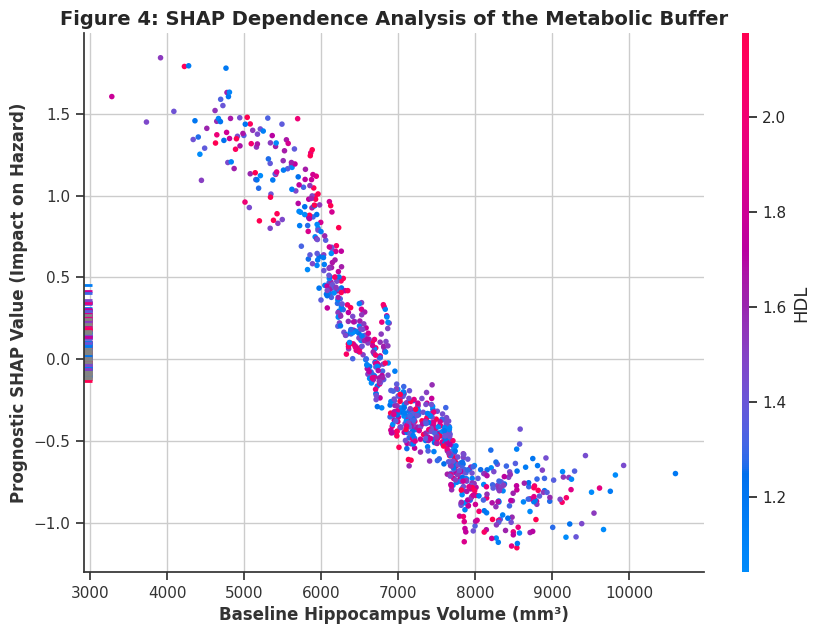

In [29]:
import shap
import matplotlib.pyplot as plt

print("Generating Figure 4: The Metabolic Buffer...")

fig, ax = plt.subplots(figsize=(10, 7))

shap.dependence_plot(
    "Hippocampus",
    shap_values,
    X_train,
    interaction_index="HDL",
    show=False,
    ax=ax
)

plt.title("Figure 4: SHAP Dependence Analysis of the Metabolic Buffer", fontsize=14, fontweight='bold')
plt.xlabel("Baseline Hippocampus Volume (mm³)", fontsize=12, fontweight='bold')
plt.ylabel("Prognostic SHAP Value (Impact on Hazard)", fontsize=12, fontweight='bold')

fig4_save = fig_path + 'Figure_4_SHAP_Dependence_Plot.png'
plt.savefig(fig4_save, dpi=300, bbox_inches='tight')
print(f"Saved to: {fig4_save}")
plt.show()

Generating Figure 2: Calibration and Hazard Curves (Fixed)...
Saved to: /content/drive/MyDrive/ADNI_Survival_Project/figures/Figure_2_Calibration_and_Hazard.png


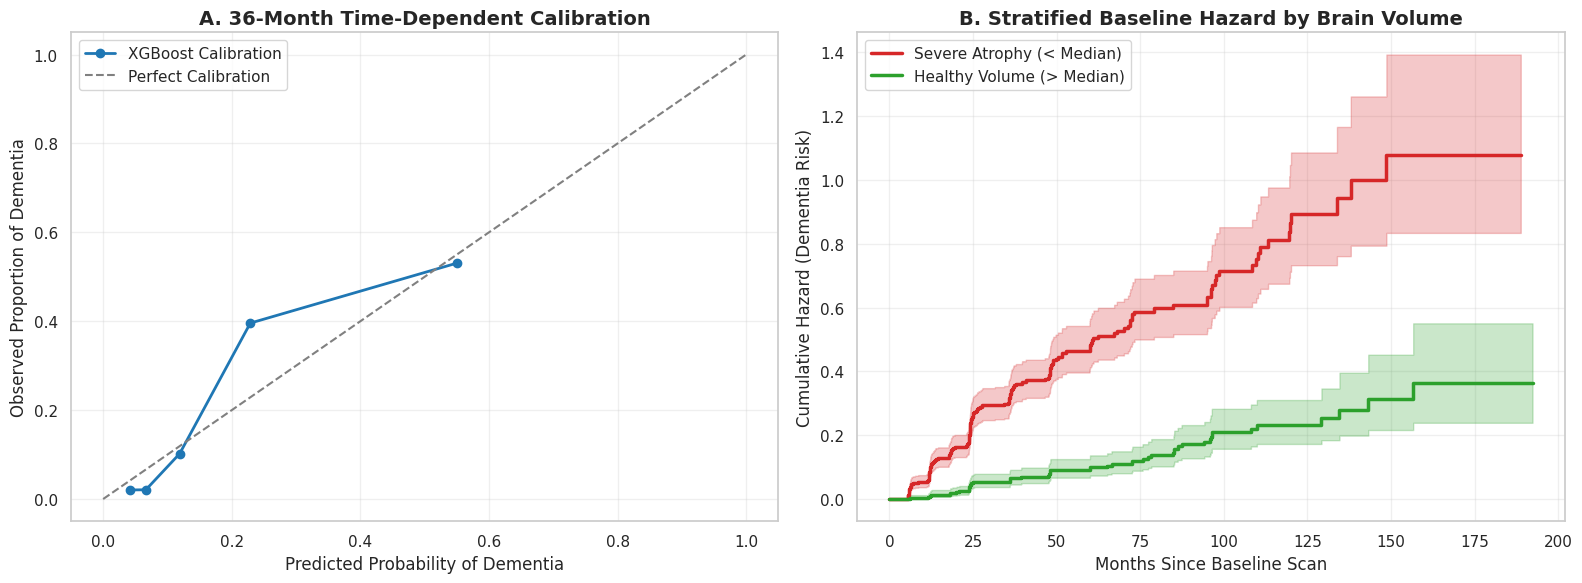

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from lifelines import NelsonAalenFitter

print("Generating Figure 2: Calibration and Hazard Curves (Fixed)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PANEL A: Calibration at 36 Months ---
S0_36 = kmf_base.predict(36)
ind_survival_probs_36 = S0_36 ** hazard_scores
valid_mask = (actual_times_array > 36) | ((actual_times_array <= 36) & (actual_events_array == 1))
valid_probs = ind_survival_probs_36[valid_mask]
actual_survival = (actual_times_array[valid_mask] > 36).astype(int)

prob_true, prob_pred = calibration_curve(1 - actual_survival, 1 - valid_probs, n_bins=5, strategy='quantile')

axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2, color='#1f77b4', label='XGBoost Calibration')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
axes[0].set_title('A. 36-Month Time-Dependent Calibration', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Dementia', fontsize=12)
axes[0].set_ylabel('Observed Proportion of Dementia', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- PANEL B: Cumulative Hazard (THE FIX) ---
# We instantiate the correct mathematical engine for Hazard curves
naf_atrophy = NelsonAalenFitter()
naf_healthy = NelsonAalenFitter()

# Find the median to split the patients
median_hippo = X_train['Hippocampus'].median()
mask_atrophy = X_train['Hippocampus'] < median_hippo
mask_healthy = X_train['Hippocampus'] >= median_hippo

# Fit the Nelson-Aalen models using the training times and events
train_times = np.abs(y_train)
train_events = (y_train > 0).astype(int)

naf_atrophy.fit(train_times[mask_atrophy], event_observed=train_events[mask_atrophy])
naf_healthy.fit(train_times[mask_healthy], event_observed=train_events[mask_healthy])

# Plot the curves
naf_atrophy.plot_cumulative_hazard(ax=axes[1], color='#d62728', linewidth=2.5, label='Severe Atrophy (< Median)')
naf_healthy.plot_cumulative_hazard(ax=axes[1], color='#2ca02c', linewidth=2.5, label='Healthy Volume (> Median)')

axes[1].set_title('B. Stratified Baseline Hazard by Brain Volume', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Months Since Baseline Scan', fontsize=12)
axes[1].set_ylabel('Cumulative Hazard (Dementia Risk)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig2_save = fig_path + 'Figure_2_Calibration_and_Hazard.png'
plt.savefig(fig2_save, dpi=300, bbox_inches='tight')
print(f"Saved to: {fig2_save}")
plt.show()